In [85]:
import pandas as pd


dataset = pd.read_csv("unique_enzymes_curated.fasta.tsv", sep="\t", header=None)
pfam_dataset = dataset[dataset.iloc[:, 3]=="Pfam"]

In [86]:
pfam_dataset = pfam_dataset.iloc[:, [0, 4, 5]]
pfam_dataset.columns = ["uniprot_id", "pfam_id", "description"]

In [ ]:
families_to_select = ["Cytochrome P450", "haloacid dehalogenase-like hydrolase", "UDP-glucoronosyl and UDP-glucosyl transferase",
                      "Methyltransferase domain", "Polyprenyl synthetase", "Glycosyl transferase family 2", "Terpene synthase, N-terminal domain",
                      ]

In [109]:
families = {
    "aminotransferase": [],
    "cytochrome p450": [],
    "glycosyl transferase": [],
    "methyltransferase": [],
    "polyprenyl synthase": [],
    "terpene synthase": [],
    "acyltransferase": []
}

for family in pfam_dataset["description"].unique():
    if "aminotransferase" in family.lower():
        families["aminotransferase"].append(family)

    elif "cytochrome p450" in family.lower():
        families["cytochrome p450"].append(family)

    elif "glycosyl transferase" in family.lower():
        families["glycosyl transferase"].append(family)

    elif "udp-glucoronosyl" in family.lower():
        families["glycosyl transferase"].append(family)

    elif "methyltransferase" in family.lower():
        families["methyltransferase"].append(family)

    elif "polyprenyl" in family.lower():
        families["polyprenyl synthase"].append(family)

    elif "terpene" in family.lower():
        families["terpene synthase"].append(family)

    elif "acyltransferase" in family.lower():
        families["acyltransferase"].append(family)

In [110]:
for key, descriptions in families.items():
    pfam_dataset.loc[pfam_dataset['description'].isin(descriptions), 'description'] = key

In [112]:
pfam_dataset.loc[~pfam_dataset['description'].isin(families.keys()), 'description'] = "Other"

In [113]:
pfam_dataset["description"].unique()

array(['Other', 'glycosyl transferase', 'aminotransferase',
       'methyltransferase', 'acyltransferase', 'polyprenyl synthase',
       'cytochrome p450', 'terpene synthase'], dtype=object)

In [114]:
pfam_dataset.drop_duplicates(subset="uniprot_id",inplace=True)

In [115]:
pfam_dataset

,uniprot_id,pfam_id,description
0,Q920P0,PF13561,Other
16,Q8A9W8,PF13419,Other
26,O60061,PF00535,glycosyl transferase
38,P18843,PF02540,Other
39,Q9H6E5,PF00076,Other
...,...,...,...
144255,Q6E7F2,PF01370,Other
144256,Q00909,PF06330,Other
144270,Q62148,PF00171,Other
144278,UGT76E11,PF00201,glycosyl transferase


In [2]:
from plants_sm.io.pickle import read_pickle

enzymes_dict = read_pickle("../dataset_integration/features_proteins_esm2_3b/features.pkl")["proteins"]
np_classifier_features = read_pickle("../dataset_integration/features_compounds_np_classifier_fp/features.pkl")["ligands"]

In [2]:

from sklearn.manifold import TSNE
import numpy as np

def generate_tsne_np_classifier(dataset, features):
    features_array = []
    for i, row in dataset.iterrows():
        id_ = row["uniprot_id"]
        features_array.append(features[id_])
    features_array = np.array(features_array)
    tsne = TSNE(n_components=2, random_state=42)
    tsne_embeddings = tsne.fit_transform(features_array)
    dataset["t-sne 1"] = tsne_embeddings[:, 0]
    dataset["t-sne 2"] = tsne_embeddings[:, 1]
    return dataset

pfam_dataset = generate_tsne_np_classifier(pfam_dataset, enzymes_dict)

NameError: name 'pfam_dataset' is not defined

In [118]:
pfam_dataset.reset_index(drop=True, inplace=True)

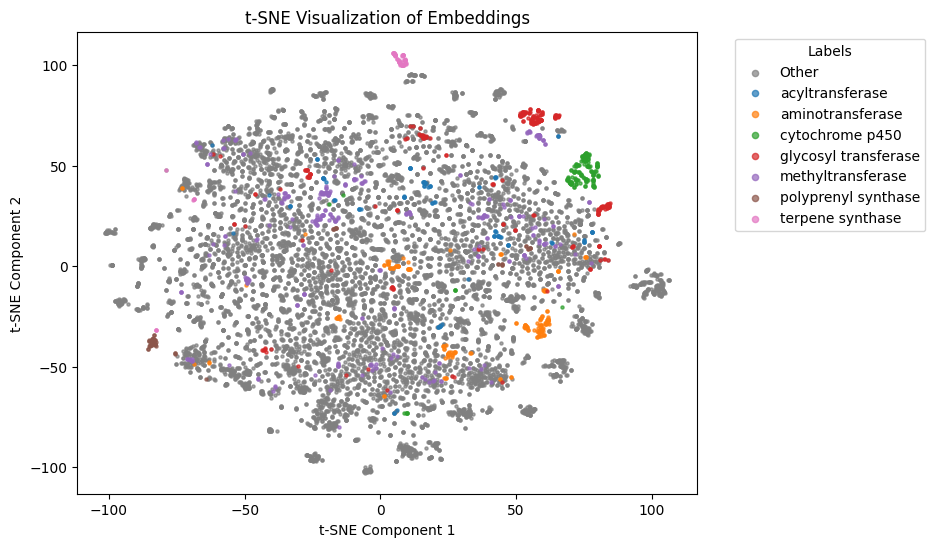

In [122]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Assuming `dataset` and `tsne_` are already defined
# Define unique colors for each class
unique_labels = np.unique(pfam_dataset.description)

# Plot with discrete colors
plt.figure(figsize=(8, 6))
for i, label in enumerate(unique_labels):
    idx = np.where(np.array(pfam_dataset.description) == str(label))[0]
    if label == "Other":
        plt.scatter(pfam_dataset.loc[idx, "t-sne 1"], pfam_dataset.loc[idx, "t-sne 2"], label=label, alpha=0.7, s=5, color="gray")
    else:
        # Use a colormap to get a color for each label
        plt.scatter(pfam_dataset.loc[idx, "t-sne 1"], pfam_dataset.loc[idx, "t-sne 2"], label=label, alpha=0.7, s=5)

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Visualization of Embeddings")

# Add a legend with bigger markers and place it outside the plot
plt.legend(title="Labels", markerscale=2, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [1]:
import pandas as pd
curated_dataset = pd.read_csv("curated_dataset.csv")
curated_dataset

,Unnamed: 0,Sequence,SMILES,Binding,Enzyme ID,Substrate ID,Publication,Validated,RHEA_ID,EC number,reaction_SMILES
0,0,MFENITAAPADPILGLADLFRADERPGKINLGIGVYKDETGKTPVL...,C(C(=O)O)N,0.0,P00509,compound_aminotransferase_dataset 1,https://pubs.acs.org/doi/10.1021/acscatal.0c01895,True,NaN,NaN,NaN
1,1,MFENITAAPADPILGLADLFRADERPGKINLGIGVYKDETGKTPVL...,C[C@@H](C(=O)O)N,1.0,P00509,compound_aminotransferase_dataset 2,https://pubs.acs.org/doi/10.1021/acscatal.0c01895,True,NaN,NaN,NaN
2,2,MFENITAAPADPILGLADLFRADERPGKINLGIGVYKDETGKTPVL...,CC(C)[C@@H](C(=O)O)N,0.0,P00509,compound_aminotransferase_dataset 3,https://pubs.acs.org/doi/10.1021/acscatal.0c01895,True,NaN,NaN,NaN
3,3,MFENITAAPADPILGLADLFRADERPGKINLGIGVYKDETGKTPVL...,CC(C)C[C@@H](C(=O)O)N,1.0,P00509,compound_aminotransferase_dataset 4,https://pubs.acs.org/doi/10.1021/acscatal.0c01895,True,NaN,NaN,NaN
4,4,MFENITAAPADPILGLADLFRADERPGKINLGIGVYKDETGKTPVL...,CC[C@H](C)[C@@H](C(=O)O)N,0.0,P00509,compound_aminotransferase_dataset 5,https://pubs.acs.org/doi/10.1021/acscatal.0c01895,True,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
73225,76466,MKYRAVTLESFGYQLAPVVVSTSDLEARLEPLYRQLRIAPGQLQAM...,C1=CC=C(C=C1)C(=O)OC2=CC=C(C=C2)[N+](=O)[O-],0.0,Pelobacter_propionicus,benzoate,https://doi.org/10.1093/synbio/ysaa004,True,NaN,NaN,NaN
73226,76467,MAFLSVNNVEIVGLAAAVPKNVETLDNLEFFAPGEAEKVMALTGIK...,C1=CC=C(C=C1)C(=O)OC2=CC=C(C=C2)[N+](=O)[O-],0.0,Bacteroides_luti,benzoate,https://doi.org/10.1093/synbio/ysaa004,True,NaN,NaN,NaN
73227,76468,MSAPRYSQVSAVAVRLPDEDLTTPELEELLAERNPRVDVPRGLIER...,C1=CC=C(C=C1)C(=O)OC2=CC=C(C=C2)[N+](=O)[O-],0.0,Nonomuraea_candida,benzoate,https://doi.org/10.1093/synbio/ysaa004,True,NaN,NaN,NaN
73228,76469,MRYQRVFINKIAYELPKEKVATSFLEEQLTDVYQELGIPLGQVEAL...,C1=CC=C(C=C1)C(=O)OC2=CC=C(C=C2)[N+](=O)[O-],0.0,Legionella_brunensis,benzoate,https://doi.org/10.1093/synbio/ysaa004,True,NaN,NaN,NaN


In [5]:
from sklearn.manifold import TSNE
import numpy as np

def generate_tsne_binding(dataset, features_compounds, features_proteins):
    features_array = []
    for i, row in dataset.iterrows():
        enzyme_id_ = row["Enzyme ID"]
        features_array.append(np.hstack((features_proteins[enzyme_id_], features_compounds[row["Substrate ID"]])))
    features_array = np.array(features_array)
    tsne = TSNE(n_components=2, random_state=42)
    tsne_embeddings = tsne.fit_transform(features_array)
    dataset["t-sne 1"] = tsne_embeddings[:, 0]
    dataset["t-sne 2"] = tsne_embeddings[:, 1]
    return dataset


np_classifier_features = read_pickle("../dataset_integration/features_compounds_np_classifier_fp/features.pkl")["ligands"]

binding = generate_tsne_binding(curated_dataset, np_classifier_features, enzymes_dict)

In [135]:
binding.reset_index(drop=True, inplace=True)

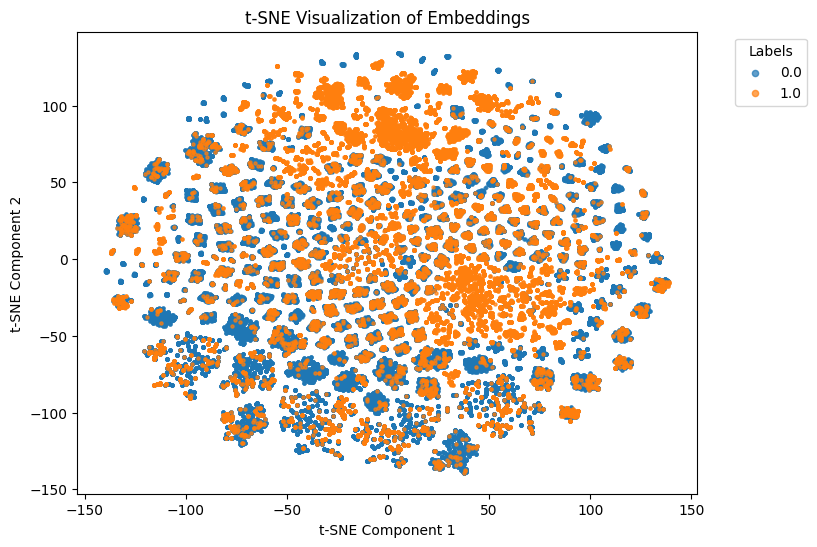

In [138]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Assuming `dataset` and `tsne_` are already defined
# Define unique colors for each class
unique_labels = np.unique(binding.Binding)

# Plot with discrete colors
plt.figure(figsize=(8, 6))
for i, label in enumerate(unique_labels):
    idx = np.where(np.array(binding.Binding) == label)[0]
    plt.scatter(binding.loc[idx, "t-sne 1"], binding.loc[idx, "t-sne 2"], label=label, alpha=0.7, s=5)

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Visualization of Embeddings")

# Add a legend with bigger markers and place it outside the plot
plt.legend(title="Labels", markerscale=2, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

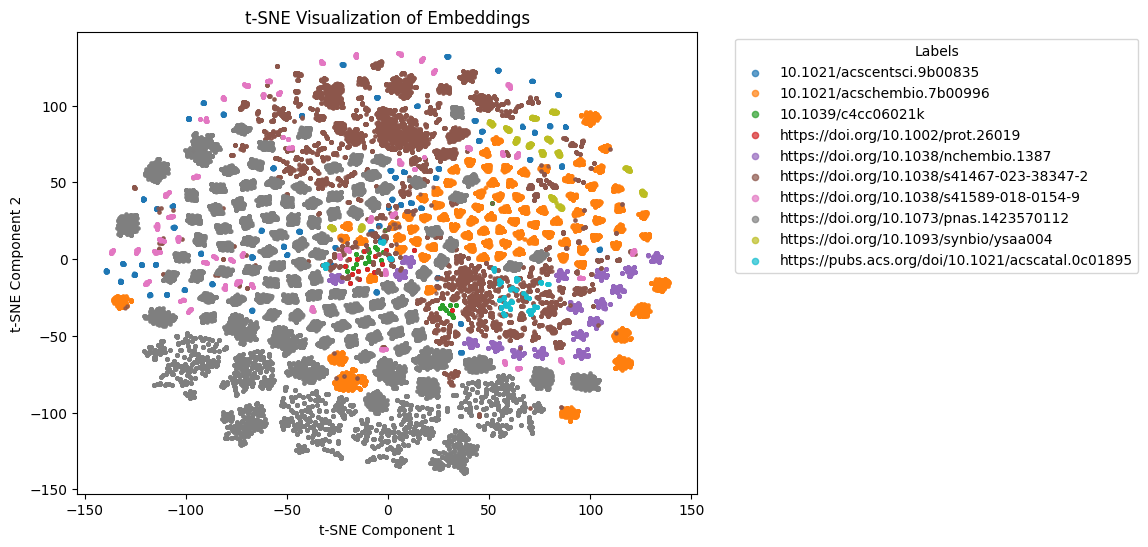

In [139]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Assuming `dataset` and `tsne_` are already defined
# Define unique colors for each class
unique_labels = np.unique(binding.Publication)

# Plot with discrete colors
plt.figure(figsize=(8, 6))
for i, label in enumerate(unique_labels):
    idx = np.where(np.array(binding.Publication) == label)[0]
    plt.scatter(binding.loc[idx, "t-sne 1"], binding.loc[idx, "t-sne 2"], label=label, alpha=0.7, s=5)

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Visualization of Embeddings")

# Add a legend with bigger markers and place it outside the plot
plt.legend(title="Labels", markerscale=2, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [149]:
binding_enzymes = pd.merge(pfam_dataset.drop(columns=["t-sne 1", "t-sne 2"]), binding, left_on="uniprot_id", right_on="Enzyme ID", how="inner")

In [150]:
binding_enzymes

,uniprot_id,pfam_id,description,Unnamed: 0,Sequence,SMILES,Binding,Enzyme ID,Substrate ID,Publication,Validated,RHEA_ID,EC number,reaction_SMILES,t-sne 1,t-sne 2
0,Q920P0,PF13561,Other,61907,MDLGLAGRRALVTGAGKGIGRSTVLALQAAGAQVVAVSRTREDLDS...,N=C([O-])c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(...,1.0,Q920P0,CHEBI:58349,https://doi.org/10.1038/s41467-023-38347-2,True,NaN,NaN,NaN,12.313643,117.065948
1,Q920P0,PF13561,Other,61908,MDLGLAGRRALVTGAGKGIGRSTVLALQAAGAQVVAVSRTREDLDS...,OC[C@@H](O)[C@H](O)[C@@H](O)CO,1.0,Q920P0,CHEBI:17151,https://doi.org/10.1038/s41467-023-38347-2,True,NaN,NaN,NaN,31.023130,-81.742599
2,Q8A9W8,PF13419,Other,3585,MDTTKTIAALFDFDGVIMDTETQYTVFWDEQGRKYLNEEDFGRRIK...,C=C(OP(=O)(O)O)C(=O)O,0.0,Q8A9W8,compound_phospatase_dataset 1,https://doi.org/10.1073/pnas.1423570112,True,NaN,NaN,NaN,-58.602249,-15.180600
3,Q8A9W8,PF13419,Other,3586,MDTTKTIAALFDFDGVIMDTETQYTVFWDEQGRKYLNEEDFGRRIK...,CC(=O)N[C@@H]1C(O)O[C@H](COP(=O)(O)O)[C@@H](O)...,1.0,Q8A9W8,compound_phospatase_dataset 2,https://doi.org/10.1073/pnas.1423570112,True,NaN,NaN,NaN,-37.035660,23.289587
4,Q8A9W8,PF13419,Other,3587,MDTTKTIAALFDFDGVIMDTETQYTVFWDEQGRKYLNEEDFGRRIK...,CC(=O)N[C@@H]1[C@@H](O)CC(O)(C(=O)O)O[C@H]1[C@...,0.0,Q8A9W8,compound_phospatase_dataset 3,https://doi.org/10.1073/pnas.1423570112,True,NaN,NaN,NaN,-94.504951,-11.614200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72088,UGT76E11,PF00201,glycosyl transferase,74812,MEEKPAGRRVVLVAVPAQGHISPIMQLAKTLHLKGFSITIAQTKFN...,C/C(=C\CNc1nc[nH]c2ncnc1-2)COC1OC(CO)C(O)C(O)C1O,0.0,UGT76E11,Trans-Zentin-Glucose,https://doi.org/10.1038/s41589-018-0154-9,True,NaN,NaN,NaN,16.699888,129.878708
72089,UGT76E11,PF00201,glycosyl transferase,74862,MEEKPAGRRVVLVAVPAQGHISPIMQLAKTLHLKGFSITIAQTKFN...,CC(CO)CCNc1nc[nH]c2ncnc1-2,0.0,UGT76E11,DihydroZeatin,https://doi.org/10.1038/s41589-018-0154-9,True,NaN,NaN,NaN,56.617374,68.475395
72090,UGT76E11,PF00201,glycosyl transferase,74912,MEEKPAGRRVVLVAVPAQGHISPIMQLAKTLHLKGFSITIAQTKFN...,Cn1cnc2c(NCc3ccccc3)[nH]c(=NCCO)nc21,0.0,UGT76E11,Olomoucine,https://doi.org/10.1038/s41589-018-0154-9,True,NaN,NaN,NaN,59.747902,113.070488
72091,UGT76E11,PF00201,glycosyl transferase,74992,MEEKPAGRRVVLVAVPAQGHISPIMQLAKTLHLKGFSITIAQTKFN...,CN[C@@H]1[C@H](O)[C@H](NC)[C@H]2O[C@@]3(O)C(=O...,0.0,UGT76E11,Spectinomycin,https://doi.org/10.1038/s41589-018-0154-9,True,NaN,NaN,NaN,-49.568748,78.066498


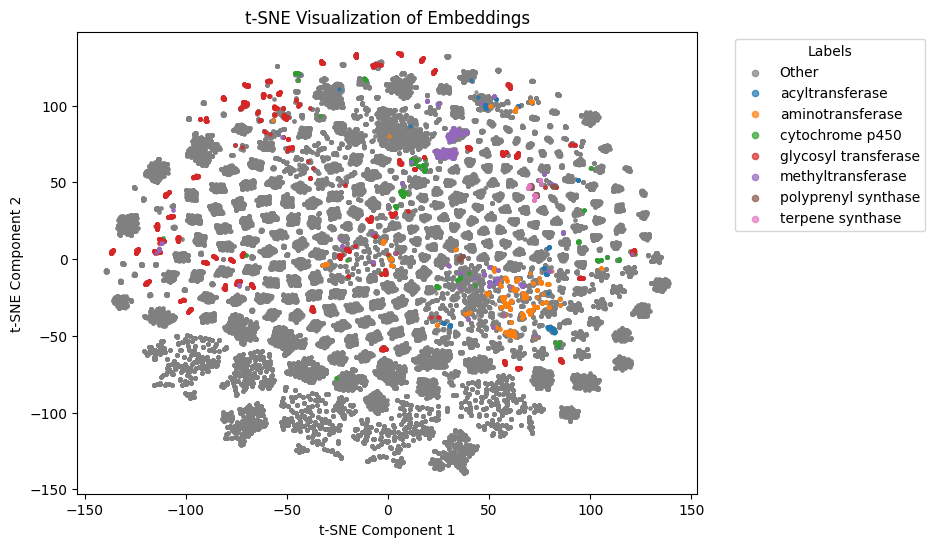

In [155]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Assuming `dataset` and `tsne_` are already defined
# Define unique colors for each class
unique_labels = np.unique(binding_enzymes.description)

# Plot with discrete colors
plt.figure(figsize=(8, 6))
for i, label in enumerate(unique_labels):
    idx = np.where(np.array(binding_enzymes.description) == label)[0]
    if label == "Other":
        plt.scatter(binding_enzymes.loc[idx, "t-sne 1"], binding_enzymes.loc[idx, "t-sne 2"], label=label, alpha=0.7, s=5, color="gray")
    else:
        # Use a colormap to get a color for each label
        plt.scatter(binding_enzymes.loc[idx, "t-sne 1"], binding_enzymes.loc[idx, "t-sne 2"], label=label, alpha=0.7, s=5)

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Visualization of Embeddings")

# Add a legend with bigger markers and place it outside the plot
plt.legend(title="Labels", markerscale=2, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [156]:
import pandas as pd

compounds_dataset = pd.read_csv("compounds_predicted_pathways.csv")
compounds_dataset["Pathways"] = compounds_dataset["Pathways"].fillna("NA")
compounds_dataset["Pathways"] = compounds_dataset["Pathways"].apply(lambda x: '>1 pathway' if len(x.split(',')) > 1 else x)
compounds_dataset["Pathways"] = compounds_dataset["Pathways"].astype(str)
compounds_dataset

,ID,SMILES,Pathways,Superclass,Class
0,compound_aminotransferase_dataset 1,NCC(=O)O,Amino acids and Peptides,Small peptides,Aminoacids
1,compound_aminotransferase_dataset 2,C[C@H](N)C(=O)O,Amino acids and Peptides,Small peptides,Aminoacids
2,compound_aminotransferase_dataset 3,CC(C)[C@H](N)C(=O)O,>1 pathway,"Fatty Acids and Conjugates, Small peptides","Amino fatty acids, Aminoacids"
3,compound_aminotransferase_dataset 4,CC(C)C[C@H](N)C(=O)O,>1 pathway,"Fatty Acids and Conjugates, Small peptides","Amino fatty acids, Aminoacids"
4,compound_aminotransferase_dataset 5,CC[C@H](C)[C@H](N)C(=O)O,>1 pathway,"Fatty Acids and Conjugates, Small peptides","Amino fatty acids, Aminoacids"
...,...,...,...,...,...
1723,heptynoate,C#CCCCCC(=O)Oc1ccc([N+](=O)[O-])cc1,Shikimates and Phenylpropanoids,Fatty Acids and Conjugates,NaN
1724,hexanoate,CCCCCC(=O)Oc1ccc([N+](=O)[O-])cc1,Shikimates and Phenylpropanoids,NaN,NaN
1725,oxidazole,O=C(CCc1nnc(-c2ccccc2)o1)Oc1ccc([N+](=O)[O-])cc1,Alkaloids,NaN,NaN
1726,TMA,CC(C)(C)C(=O)Oc1ccc([N+](=O)[O-])cc1,Alkaloids,NaN,NaN


In [161]:
binding_compounds = pd.merge(compounds_dataset, binding, left_on="ID", right_on="Substrate ID", how="inner")
binding_compounds

,ID,SMILES_x,Pathways,Superclass,Class,Unnamed: 0,Sequence,SMILES_y,Binding,Enzyme ID,Substrate ID,Publication,Validated,RHEA_ID,EC number,reaction_SMILES,t-sne 1,t-sne 2
0,compound_aminotransferase_dataset 1,NCC(=O)O,Amino acids and Peptides,Small peptides,Aminoacids,0,MFENITAAPADPILGLADLFRADERPGKINLGIGVYKDETGKTPVL...,C(C(=O)O)N,0.0,P00509,compound_aminotransferase_dataset 1,https://pubs.acs.org/doi/10.1021/acscatal.0c01895,True,NaN,NaN,NaN,54.729206,-16.511814
1,compound_aminotransferase_dataset 1,NCC(=O)O,Amino acids and Peptides,Small peptides,Aminoacids,18,MDYVTLASHAVRQYAPDQIFTASQRAKADAAALGEDAVINATLGEC...,C(C(=O)O)N,0.0,A0A174XK40,compound_aminotransferase_dataset 1,https://pubs.acs.org/doi/10.1021/acscatal.0c01895,True,NaN,NaN,NaN,54.983120,-13.557543
2,compound_aminotransferase_dataset 1,NCC(=O)O,Amino acids and Peptides,Small peptides,Aminoacids,36,MFQKVDAYAGDPILTLMERFKEDPRSDKVNLSIGLYYNEDGIIPQL...,C(C(=O)O)N,0.0,P04693,compound_aminotransferase_dataset 1,https://pubs.acs.org/doi/10.1021/acscatal.0c01895,True,NaN,NaN,NaN,54.942249,-13.900771
3,compound_aminotransferase_dataset 1,NCC(=O)O,Amino acids and Peptides,Small peptides,Aminoacids,54,MFQKVDAYAGDPILSLMERFKEDPRSDKVNLSIGLYYNDDGIIPQL...,C(C(=O)O)N,0.0,A0A3N0RMA5,compound_aminotransferase_dataset 1,https://pubs.acs.org/doi/10.1021/acscatal.0c01895,True,NaN,NaN,NaN,54.946186,-13.933659
4,compound_aminotransferase_dataset 1,NCC(=O)O,Amino acids and Peptides,Small peptides,Aminoacids,72,MSPIEKSSKLENVCYDIRGPVLKEAKRLEEEGNKVLKLNIGNPAPF...,C(C(=O)O)N,0.0,P0A959,compound_aminotransferase_dataset 1,https://pubs.acs.org/doi/10.1021/acscatal.0c01895,True,NaN,NaN,NaN,54.715099,-16.511211
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73225,benzoate,O=C(Oc1ccc([N+](=O)[O-])cc1)c1ccccc1,Shikimates and Phenylpropanoids,Phenolic acids (C6-C1),Simple phenolic acids,76466,MKYRAVTLESFGYQLAPVVVSTSDLEARLEPLYRQLRIAPGQLQAM...,C1=CC=C(C=C1)C(=O)OC2=CC=C(C=C2)[N+](=O)[O-],0.0,Pelobacter_propionicus,benzoate,https://doi.org/10.1093/synbio/ysaa004,True,NaN,NaN,NaN,-27.168997,20.916292
73226,benzoate,O=C(Oc1ccc([N+](=O)[O-])cc1)c1ccccc1,Shikimates and Phenylpropanoids,Phenolic acids (C6-C1),Simple phenolic acids,76467,MAFLSVNNVEIVGLAAAVPKNVETLDNLEFFAPGEAEKVMALTGIK...,C1=CC=C(C=C1)C(=O)OC2=CC=C(C=C2)[N+](=O)[O-],0.0,Bacteroides_luti,benzoate,https://doi.org/10.1093/synbio/ysaa004,True,NaN,NaN,NaN,-28.879953,21.554655
73227,benzoate,O=C(Oc1ccc([N+](=O)[O-])cc1)c1ccccc1,Shikimates and Phenylpropanoids,Phenolic acids (C6-C1),Simple phenolic acids,76468,MSAPRYSQVSAVAVRLPDEDLTTPELEELLAERNPRVDVPRGLIER...,C1=CC=C(C=C1)C(=O)OC2=CC=C(C=C2)[N+](=O)[O-],0.0,Nonomuraea_candida,benzoate,https://doi.org/10.1093/synbio/ysaa004,True,NaN,NaN,NaN,-26.617317,19.457808
73228,benzoate,O=C(Oc1ccc([N+](=O)[O-])cc1)c1ccccc1,Shikimates and Phenylpropanoids,Phenolic acids (C6-C1),Simple phenolic acids,76469,MRYQRVFINKIAYELPKEKVATSFLEEQLTDVYQELGIPLGQVEAL...,C1=CC=C(C=C1)C(=O)OC2=CC=C(C=C2)[N+](=O)[O-],0.0,Legionella_brunensis,benzoate,https://doi.org/10.1093/synbio/ysaa004,True,NaN,NaN,NaN,-29.052879,21.002542


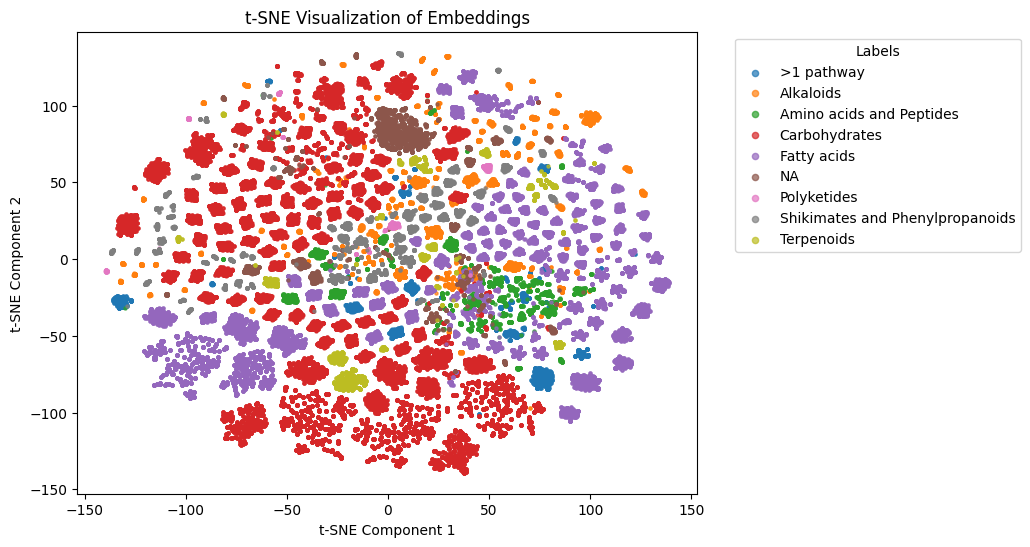

In [162]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Assuming `dataset` and `tsne_` are already defined
# Define unique colors for each class
unique_labels = np.unique(binding_compounds.Pathways)

# Plot with discrete colors
plt.figure(figsize=(8, 6))
for i, label in enumerate(unique_labels):
    idx = np.where(np.array(binding_compounds.Pathways) == label)[0]
    if label == "Other":
        plt.scatter(binding_compounds.loc[idx, "t-sne 1"], binding_compounds.loc[idx, "t-sne 2"], label=label, alpha=0.7, s=5, color="gray")
    else:
        # Use a colormap to get a color for each label
        plt.scatter(binding_compounds.loc[idx, "t-sne 1"], binding_compounds.loc[idx, "t-sne 2"], label=label, alpha=0.7, s=5)

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Visualization of Embeddings")

# Add a legend with bigger markers and place it outside the plot
plt.legend(title="Labels", markerscale=2, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()